<a href="https://colab.research.google.com/github/Sameer248-r/Machine-learning-practice/blob/main/linear_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import necessary labrires**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving student_scores.csv to student_scores.csv


In [ ]:
df = pd.read_csv("/content/student_scores.csv")
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


**Based on number of study build an ml model to predict the score**

--> is there any categorical column -- no
--> we have two columns -- hours(float) | scores(int)

In [ ]:
df.shape

(25, 2)

**Data Jar**

In [ ]:
#we clean , encode, split and scale the data
# scaling is not mandatory in LR

**1. Data Cleaning**

In [ ]:
#1. check the data types
df.dtypes
# #2. check null values
df.isnull().sum()
# #3. check the outliers in the data
# #checking the outliers by using Inter Quartile range (IQR)
# #get the descriptive stats of the data
df.describe()
# df.duplicated()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
#find the iqr value --> 75%-25%
iqr = df['Hours'].quantile(0.75) - df['Hours'].quantile(0.25)
print(iqr)

4.7


In [ ]:
print(7.4-2.7)

4.7


In [ ]:
# find the upper limit or maximum limit
# upper limit = Q3 + 1.5(iqr)

UL = 7.4 + 1.5*(4.7)
print(UL)

14.450000000000001


In [ ]:
#lower_limit = Q1 - 1.5(iqr)
LL = 2.7 - 1.5*(4.7)
print(LL)

-4.3500000000000005


In [ ]:
df.describe()
#in the hours column min--> 1.1
#max value--> 7.4
#UL = 14.45
#LL = -4.35

#[-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,...]
# wheh the maximum and minimum vlue present within the range of UL and LL then there is no outliers in data

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
# check the duplicates
df.duplicated().sum()


np.int64(0)

  1. there is no null values
  2. the data type format is correct
  3. no duplicates to drop
  4. no outliers

**2. encoding the data**
--> in the given dataset there is no c ategorical column so we no need to encode the data

**3. Split the data**

--> before spliting the data we need to define the features(x)
and target variables(y)

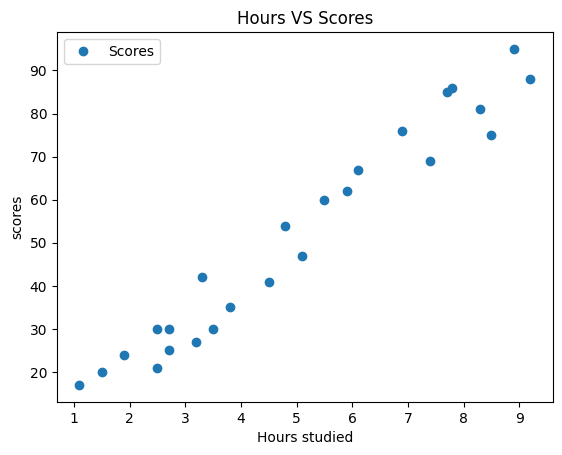

In [ ]:
# check the linear relationship between data
df.plot(x='Hours',y='Scores',style='o')
plt.xlabel('Hours studied')
plt.ylabel("scores")
plt.title("Hours VS Scores")
plt.show()


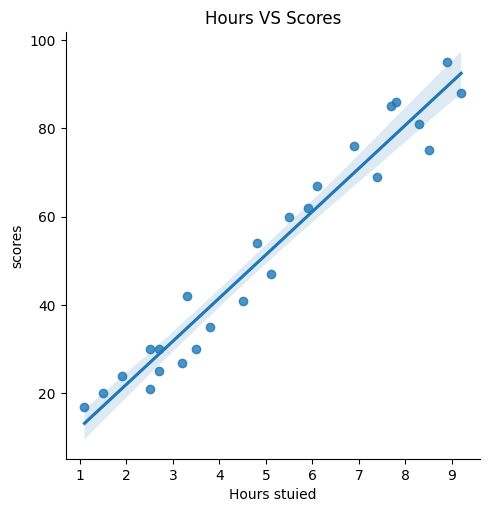

In [ ]:
# lmplot--> used for statistical estimtion

sns.lmplot(data=df,x="Hours",y="Scores")
plt.xlabel('Hours stuied')
plt.ylabel("scores")
plt.title("Hours VS Scores")
plt.show()


1. there is a staright line between hours and scores
2. no transformation is required

In [ ]:
# another way to check the strenght of linear relation is use co-relation
df.corr()

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


define the feature and target varaible

In [ ]:
df['Hours']

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [ ]:
x = df.loc[:,['Hours']].values # featue in 2D
y = df.loc[:,'Scores'].values # target in Series

In [ ]:
x
y

array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
       24, 67, 69, 30, 54, 35, 76, 86])

split the data in to train and test

In [ ]:
# train --> 70 to 80%
# test --> 20 to 30%
# import
from sklearn.model_selection import train_test_split
X_train,X_test,y_tarin,y_test = train_test_split(x,y,test_size=0.25,random_state=46)
X_train

array([[4.5],
       [2.7],
       [7.7],
       [1.9],
       [3.8],
       [9.2],
       [5.5],
       [2.5],
       [6.9],
       [3.2],
       [4.8],
       [2.5],
       [5.9],
       [6.1],
       [7.4],
       [2.7],
       [8.3],
       [1.5]])

In [ ]:
#RANDOM_SATET is used to get the fixed samples or stabel samples

**scaling is noty mandatory for LR**

**Task jar:- supervised learning task**

--> we deal with labeld data means we know the target variable

**Model Jar:- matehmatical representation of LR**

In [ ]:
# y= mx+c
from sklearn.linear_model import LinearRegression
#intialize the lR
regressor = LinearRegression()
# # fit the training data
regressor.fit(X_train,y_tarin) # all the magic happens here means loss function MAE,MSE,gradient desient

LinearRegression()

In [ ]:
#"c is known interception"
print(regressor.intercept_)

1.7944044718360317


In [ ]:
#"m" slope(xoef_)
print(regressor.coef_)

[9.90471549]


In [ ]:
#predict score y =9.9 * x + 1.79
regressor.predict([[4.5]])

array([46.36562419])

In [ ]:
y_pred = regressor.predict(X_test)
y_pred

array([85.98448617, 52.30845349, 89.94637237, 79.05118532, 36.4609087 ,
       34.4799656 , 12.68959151])

In [ ]:
data = pd.DataFrame({"actual":y_test,"predicted":y_pred})
data

,actual,predicted
0,75,85.984486
1,47,52.308453
2,95,89.946372
3,86,79.051185
4,30,36.460909
5,42,34.479966
6,17,12.689592


**check with another random state**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_tarin,y_test = train_test_split(x,y,test_size = 0.25,random_state=25)

In [ ]:
from sklearn.linear_model import LinearRegression
#intialize the lR
regressor = LinearRegression()
# fit the training data
regressor.fit(X_train,y_tarin) # all the magic happens here means loss function MAE,MSE,gradient desient

LinearRegression()

In [ ]:
y_pred = regressor.predict(X_test)
y_pred

array([34.07825416, 29.32354953, 21.71602212, 76.87059582, 49.29330897,
       35.02919508, 27.42166768])

In [ ]:
data = pd.DataFrame({"actual":y_test,"predicted":y_pred})
data

,actual,predicted
0,27,34.078254
1,25,29.323550
2,24,21.716022
3,85,76.870596
4,54,49.293309
5,42,35.029195
6,21,27.421668


**6th evaluation jar--R2-score**

In [ ]:
from sklearn import metrics
print("R2-Score",metrics.r2_score(y_test,y_pred))

R2-Score 0.9220871666663775


In [ ]:
y_test

array([27, 25, 24, 85, 54, 42, 21])

1.my linera regression model is predicted 92% of values are correct.

2.in general if the model ecalution score is more than 75% then it is good model